BFS Traversal: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


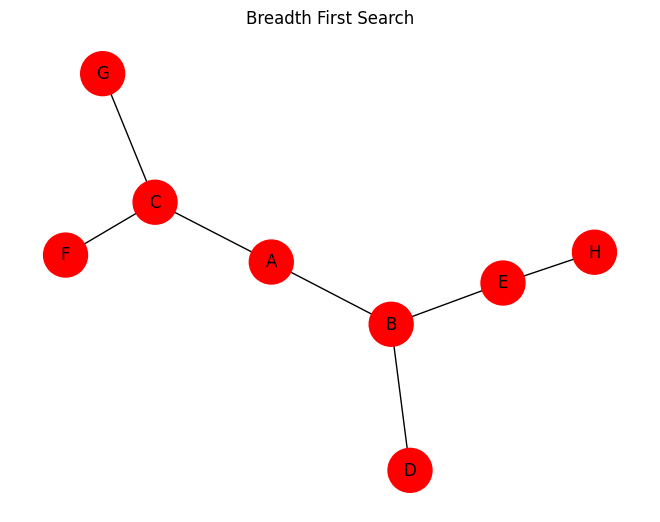

In [8]:
import networkx as nx

 # NetworkX is a Python package used to create,
 # manipulate, analyze, and visualize graphs and networks.

import matplotlib.pyplot as plt
from collections import deque

 # deque (Double-Ended Queue) is imported from
 # Python’s built-in collections module.
 # BFS follows FIFO (First In First Out) principle.
 # The first node inserted into the queue is
 # the first node removed.

 # Create Graph
G = nx.Graph() # Creates an empty graph

edges = [
('A','B'), ('A' ,'C'),
('B' ,'D'), ('B' ,'E'),
('C' ,'F'), ('C' ,'G'),
('E' ,'H')
]

G.add_edges_from(edges)


 # Breadth First Search (BFS)

start = 'A'

visited = []

queue = deque([start])


while queue:
    node = queue.popleft()

    if node not in visited:

        visited.append(node)

        queue.extend(
        sorted(set(G.neighbors(node))
-set(visited))
        )


print("BFS Traversal:", visited)


 # Draw Graph

pos = nx.spring_layout(G, seed=42)


node_colors = [
'red' if node in visited
else 'lightblue'
for node in G.nodes()
]


nx.draw(
G,
pos,
with_labels=True,
node_size=1000,
node_color=node_colors,
font_size=12
)


plt.title("Breadth First Search")

plt.show()

program   For Animated Visualisations Of BFS

BFS Traversal Order:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


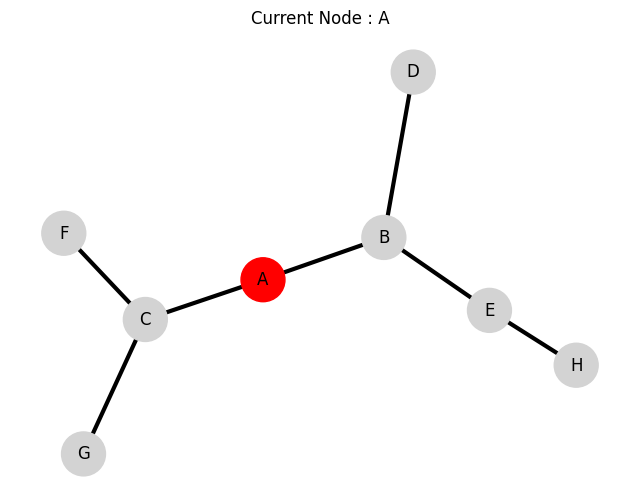

In [7]:
# Import required libraries

import networkx as nx
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from collections import deque

from IPython.display import HTML


# Create graph

G = nx.Graph()


edges = [
('A','B'),
('A','C'),
('B','D'),
('B','E'),
('C','F'),
('C','G'),
('E','H')
]


G.add_edges_from(edges)


# BFS Traversal

visited = []
parent = {}
queue = deque(['A'])


while queue:

    node = queue.popleft()

    if node not in visited:

        visited.append(node)

        for neighbour in sorted(G.neighbors(node)):

            if neighbour not in visited and neighbour not in queue:

                parent[neighbour] = node
                queue.append(neighbour)



print("BFS Traversal Order:")
print(visited)



# Graph Layout

pos = nx.spring_layout(G, seed=5)


fig, ax = plt.subplots(figsize=(8,6))


# Animation Function

def update(frame):

    ax.clear()
    visited_now = visited[:frame+1]


    node_colors = [
    'red' if n in visited_now else 'lightgray'
    for n in G.nodes()
    ]


    edge_colors = []


    for u,v in G.edges():

        if ((v in parent and parent[v] == u and v in visited_now)
or
        (u in parent and parent[u] == v and u in visited_now)
        ):

            edge_colors.append('green')

        else:

            edge_colors.append('black')


    nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    node_size=1000,
    width=3
    )


    ax.set_title(
    f"Current Node : {visited[frame]}"
    )
# Generate Animation

ani = FuncAnimation(
    fig,
    update,
    frames=len(visited),
    interval=1200,
    repeat=False
)

# Display animation

HTML(ani.to_jshtml())